# Tutorial 02 | Fourier-domain diffusion on Paul15

Trains a multi-band score network on the Fourier spectrum of gene expression
and validates that generated cells preserve the real spectral structure.

> **Preprocessing** uses the shared `sjd.pp.prepare_trajectory` API.
> The Fourier model itself is a separate extension.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import torch
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
import scjdo as sjd

from scjdo.fourier.transforms import dft, idft, pack_ri, unpack_ri
from scjdo.fourier.bands import split_bands, merge_bands
from scjdo.fourier.features import power_spectrum_features
from scjdo.fourier.losses_spectral import band_weighted_score_loss, spectral_smoothness_loss
from scjdo.models.fourier_score_network import MultiBandScoreNet
from scjdo.training.fourier_trainer import SpectralDiffusionTrainer
from scjdo.fourier.sample import sample

# ── Configuration ──────────────────────────────────────────────────────────
SPLITS        = (0.2, 0.6)   # band boundaries: low / mid / high
EPOCHS        = 200
BATCH_SIZE    = 256
SIGMA_MIN     = 0.01
SIGMA_MAX     = 3.0
SPECTRAL_W    = 0.02
N_GEN         = 500
STEPS         = 200
OUTDIR        = 'results/02_fourier/'
os.makedirs(OUTDIR, exist_ok=True)
print(f'scjdo v{sjd.__version__}')

scjdo v0.3.0


## 1. Load and preprocess

In [2]:
adata = sc.datasets.paul15()

sjd.pp.prepare_trajectory(
    adata,
    groupby      = 'paul15_clusters',
    root         = '7MEP',
    n_hvg        = 2000,
    compute_umap = True,
)

# Keep log1p layer for Fourier analysis
X_log = torch.tensor(adata.X.toarray() if hasattr(adata.X, 'toarray') else adata.X,
                     dtype=torch.float32)
G = X_log.shape[1]
print(f"Expression tensor: {tuple(X_log.shape)}")

Expression tensor: (2730, 2000)


## 2. Spectral analysis — power spectrum and band energies

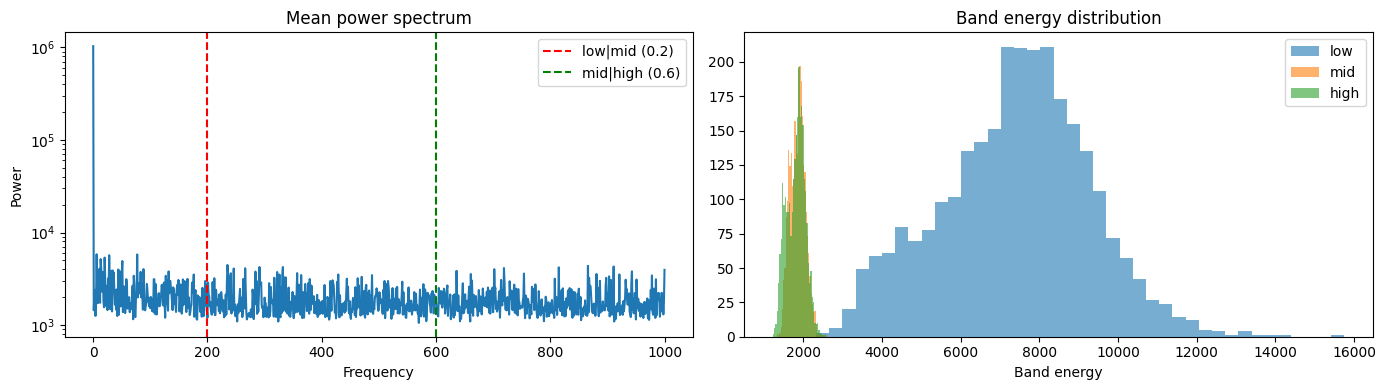

In [5]:
import os

X_hat = dft(X_log)                                # Fourier transform
K = X_hat.shape[-1]

ps = (X_hat.abs() ** 2).mean(0).detach().cpu().numpy()   # mean power spectrum
freqs = np.arange(K)

lo_end = int(K * SPLITS[0])
hi_start = int(K * SPLITS[1])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].semilogy(freqs, ps)
axes[0].set_xlabel("Frequency")
axes[0].set_ylabel("Power")
axes[0].axvline(lo_end, ls="--", color="r", label=f"low|mid ({SPLITS[0]})")
axes[0].axvline(hi_start, ls="--", color="g", label=f"mid|high ({SPLITS[1]})")
axes[0].legend()
axes[0].set_title("Mean power spectrum")

feats = power_spectrum_features(X_hat, splits=SPLITS)   # dict
ps_all = feats["ps_all"]                                # shape: (N, 3)

for i, band in enumerate(["low", "mid", "high"]):
    axes[1].hist(
        ps_all[:, i].detach().cpu().numpy(),
        bins=40,
        alpha=0.6,
        label=band,
    )

axes[1].set_xlabel("Band energy")
axes[1].legend()
axes[1].set_title("Band energy distribution")

plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "power_spectrum.pdf"), dpi=150, bbox_inches="tight")
plt.show()

## 3. Train the Fourier score network

Epoch 50/200  DSM=0.0000  Spectral=0.0000
Epoch 100/200  DSM=0.0000  Spectral=0.0000
Epoch 150/200  DSM=0.0000  Spectral=0.0000
Epoch 200/200  DSM=0.0000  Spectral=0.0000


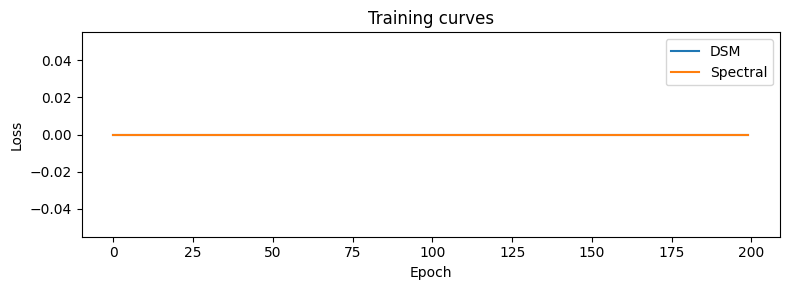

In [9]:
import os
from torch.utils.data import TensorDataset, DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"

fourier_model = MultiBandScoreNet(
    gene_dim=G,
    hidden_dim=256,
    band_splits=SPLITS,
).to(device)

optimizer = torch.optim.Adam(fourier_model.parameters(), lr=3e-4)

trainer = SpectralDiffusionTrainer(
    model=fourier_model,
    optimizer=optimizer,
    device=device,
    sigma_min=SIGMA_MIN,
    sigma_max=SIGMA_MAX,
    spectral_weight=SPECTRAL_W,
    grad_clip=1.0,
)

dataset = TensorDataset(X_log)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

losses_dsm, losses_spec = [], []

for epoch in range(EPOCHS):
    fourier_model.train()
    ep_dsm, ep_spec = [], []

    for (xb,) in loader:
        xb = xb.to(device)

        stats = trainer.train_step(xb)

        ep_dsm.append(float(stats.get("dsm_loss", 0)))
        ep_spec.append(float(stats.get("spectral_loss", 0)))

    losses_dsm.append(np.mean(ep_dsm))
    losses_spec.append(np.mean(ep_spec))

    if (epoch + 1) % 50 == 0:
        print(
            f"Epoch {epoch + 1}/{EPOCHS}  "
            f"DSM={losses_dsm[-1]:.4f}  "
            f"Spectral={losses_spec[-1]:.4f}"
        )

plt.figure(figsize=(8, 3))
plt.plot(losses_dsm, label="DSM")
plt.plot(losses_spec, label="Spectral")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training curves")
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "training_curves.pdf"), dpi=150, bbox_inches="tight")
plt.show()

## 4. Generate synthetic cells and validate spectra

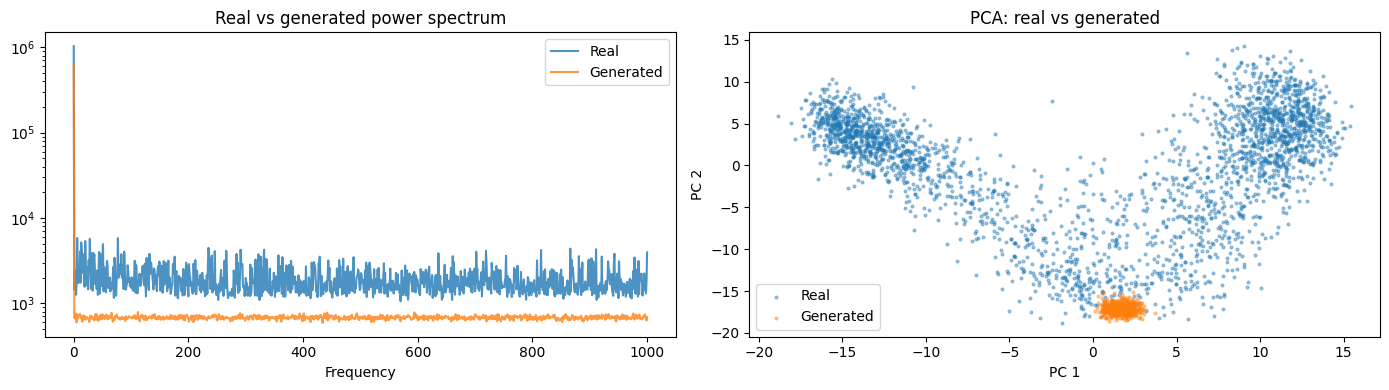

Generated cells: torch.Size([500, 2000])


In [10]:
fourier_model.eval()
X_gen = sample(model=fourier_model, shape=(N_GEN, G), steps=STEPS,
               sigma_min=SIGMA_MIN, sigma_max=SIGMA_MAX)
X_gen = X_gen.clamp(min=0., max=float(X_log.max()))

# Compare power spectra
X_gen_hat = dft(X_gen)
ps_real   = (X_hat.abs() ** 2).mean(0).numpy()
ps_gen    = (X_gen_hat.abs() ** 2).mean(0).numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].semilogy(ps_real, label='Real', alpha=0.8)
axes[0].semilogy(ps_gen,  label='Generated', alpha=0.8)
axes[0].set_xlabel('Frequency'); axes[0].legend(); axes[0].set_title('Real vs generated power spectrum')

# PCA overlay
from sklearn.decomposition import PCA
pca = PCA(n_components=2).fit(X_log.numpy())
real_2d = pca.transform(X_log.numpy())
gen_2d  = pca.transform(X_gen.numpy())
axes[1].scatter(real_2d[:, 0], real_2d[:, 1], s=4, alpha=0.4, label='Real')
axes[1].scatter(gen_2d[:, 0],  gen_2d[:, 1],  s=4, alpha=0.4, label='Generated')
axes[1].set_xlabel('PC 1'); axes[1].set_ylabel('PC 2')
axes[1].legend(); axes[1].set_title('PCA: real vs generated')

plt.tight_layout(); plt.savefig(OUTDIR + 'real_vs_generated.pdf', dpi=150); plt.show()
print(f"Generated cells: {X_gen.shape}")

## 5. Top genes per frequency band

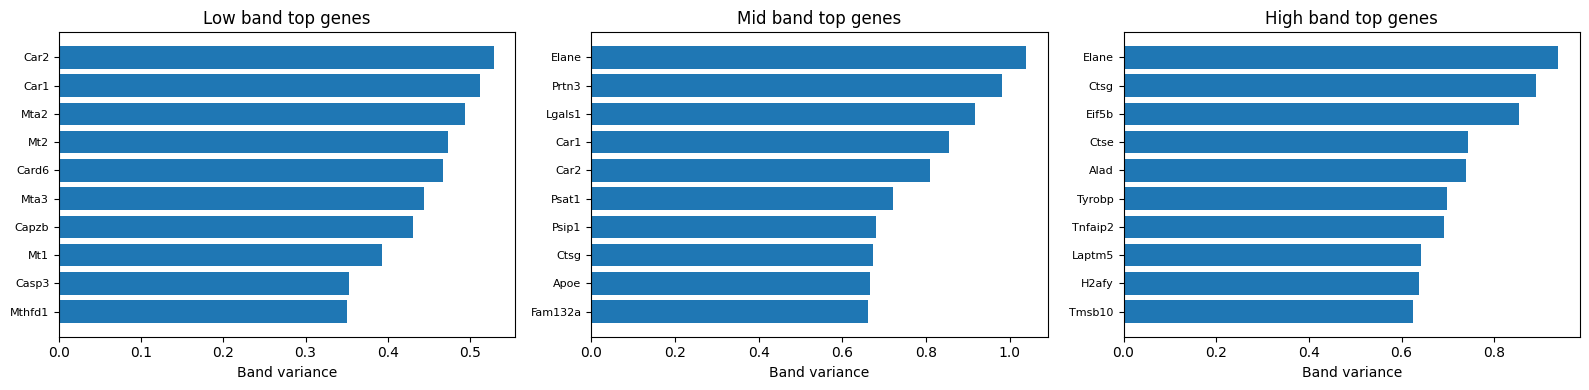

In [11]:
bands = split_bands(X_hat, splits=SPLITS)
gene_names = list(adata.var_names)
top_k = 10

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (band_name, band_data) in zip(axes, bands.items()):
    band_recon = idft(band_data, n=G).real
    band_var   = band_recon.var(0).numpy()
    top_idx    = np.argsort(band_var)[::-1][:top_k]
    top_names  = [gene_names[i] for i in top_idx]
    ax.barh(range(top_k), band_var[top_idx][::-1])
    ax.set_yticks(range(top_k)); ax.set_yticklabels(top_names[::-1], fontsize=8)
    ax.set_xlabel('Band variance'); ax.set_title(f'{band_name.capitalize()} band top genes')

plt.tight_layout(); plt.savefig(OUTDIR + 'band_genes.pdf', dpi=150); plt.show()

## 6. Save

In [12]:
torch.save({'model': fourier_model.state_dict(), 'splits': SPLITS,
            'sigma_min': SIGMA_MIN, 'sigma_max': SIGMA_MAX},
           OUTDIR + 'fourier_model.pt')
print(f"Model saved to {OUTDIR}fourier_model.pt")

Model saved to results/02_fourier/fourier_model.pt
